# Lab 0 — Build a Tiny World

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab00_tiny_world/notebook.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 0**

Before we *learn* a world model (Lab 2), we need to understand what a "world" even is in the RL sense: a **state** that fully describes the situation, **actions** that perturb it, a **transition function** that moves it forward in time, and **observations** that are all an agent ever gets to see.

In this lab you will implement a tiny 2D physics world from scratch with pure NumPy — no gym, no black boxes. Every line of the environment loop will be yours, which is exactly the point: a learned world model later is just a stand-in for the transition function you are about to write by hand.

## Setup

**Why this cell exists:** the only third-party package we need beyond the scientific-Python stack is `imageio` (for writing GIFs). Colab ships NumPy and Matplotlib preinstalled; the cell below installs the rest only when needed, so the notebook runs identically on Colab and on a local Jupyter.

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg in ["imageio"]:
    ensure(pkg)

import os
import importlib.metadata
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

%matplotlib inline
os.makedirs("assets", exist_ok=True)
print("numpy", np.__version__, "| imageio", importlib.metadata.version("imageio"))

numpy 2.0.2 | imageio 2.37.2


## 1. The World: state, action, transition

**Why we care:** a *world model* is, at its core, a function `p(s_{t+1} | s_t, a_t)`. If we want to learn such a function (Lab 2), we should first build one analytically so we know exactly what the learning algorithm is trying to approximate.

Our tiny world:

- **State** `s = (x, y, vx, vy)` — position and velocity of a ball in the unit square `[0, 1]²`.
- **Action** `a = (ax, ay) ∈ {-1, 0, 1}²` — a force push, one of 9 discrete actions.
- **Transition** — *semi-implicit Euler*: update velocity with the force and friction **first**, then move the position with the *new* velocity. This ordering is more stable than naive Euler and is the standard choice in game physics.
- **Walls** — if the ball leaves the square, its position is reflected and its velocity is flipped and damped (inelastic bounce).
- **Reward** — negative distance to a goal point: `r = -||p_ball - p_goal||`.

**Why semi-implicit Euler?** Explicit Euler (`x += v*dt` then `v += a*dt`) adds energy to oscillating systems and can blow up; updating velocity first and then using it for the position keeps the simulation stable at large `dt`, which lets us use cheap, fast rollouts.

In [2]:
class MovingBallWorld:
    # A tiny 2D physics world: a ball in the unit square, pushed by force actions.
    ACTION_TABLE = [(ax, ay) for ax in (-1, 0, 1) for ay in (-1, 0, 1)]  # 9 actions

    def __init__(self, size=64, dt=0.1, friction=0.98, bounce=0.8,
                 force_scale=2.0, obs_noise=0.5, seed=None):
        self.size = size              # rendered image is size x size pixels
        self.dt = dt                  # integration time step
        self.friction = friction      # velocity decay per step, in (0, 1]
        self.bounce = bounce          # fraction of velocity kept after a wall hit
        self.force_scale = force_scale
        self.obs_noise = obs_noise    # std of position-observation noise, in pixels
        self.rng = np.random.default_rng(seed)
        self.state = None             # (x, y, vx, vy) in normalized coordinates
        self.goal = None              # (gx, gy)

    # ----- the two core API methods -----
    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        margin = 0.15
        x, y = self.rng.uniform(margin, 1 - margin, size=2)
        self.state = np.array([x, y, 0.0, 0.0])
        self.goal = self.rng.uniform(margin, 1 - margin, size=2)
        return self.observe()

    def step(self, action):
        ax, ay = self.ACTION_TABLE[action] if np.isscalar(action) else action
        x, y, vx, vy = self.state

        # semi-implicit Euler: velocity first (force + friction), then position
        vx = (vx + self.force_scale * ax * self.dt) * self.friction
        vy = (vy + self.force_scale * ay * self.dt) * self.friction
        x = x + vx * self.dt
        y = y + vy * self.dt

        # inelastic wall bounce: reflect position, flip + damp velocity
        if x < 0: x, vx = -x, -vx * self.bounce
        if x > 1: x, vx = 2 - x, -vx * self.bounce
        if y < 0: y, vy = -y, -vy * self.bounce
        if y > 1: y, vy = 2 - y, -vy * self.bounce

        self.state = np.array([x, y, vx, vy])
        reward = -float(np.linalg.norm(self.state[:2] - self.goal))
        done = reward > -0.05  # close enough to the goal
        return self.observe(), reward, done, {"state": self.state.copy()}

    # ----- observations: what the agent is allowed to see -----
    def observe(self):
        noise = self.rng.normal(0.0, self.obs_noise / self.size, size=2)
        return {"position": self.state[:2] + noise, "image": self.render()}

    def render(self):
        # 64x64 RGB: white ball, red goal marker
        img = np.zeros((self.size, self.size, 3), dtype=np.uint8)
        px = int(np.clip(self.state[0], 0, 1) * (self.size - 1))
        py = int(np.clip(self.state[1], 0, 1) * (self.size - 1))
        yy, xx = np.mgrid[0:self.size, 0:self.size]
        ball = (xx - px) ** 2 + (yy - py) ** 2 <= 3 ** 2
        img[ball] = [255, 255, 255]
        gx = int(self.goal[0] * (self.size - 1))
        gy = int(self.goal[1] * (self.size - 1))
        img[max(gy - 1, 0):gy + 2, max(gx - 1, 0):gx + 2] = [255, 0, 0]
        return img

print("MovingBallWorld defined. Actions:", MovingBallWorld.ACTION_TABLE)

MovingBallWorld defined. Actions: [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 0), (0, 1), (1, -1), (1, 0), (1, 1)]


## 2. Smoke test: reset and step

**Why:** always verify the invariants of a simulator before trusting rollouts — state shape, reward sign, and that a force actually moves the ball. Catching a sign error here is much cheaper than debugging a learned model trained on broken data later.

initial state (hidden from agent): [0.692 0.457 0.    0.   ]
observed position (noisy):         [0.677 0.447]
observed image shape:              (64, 64, 3) uint8
t=0  state=[ 0.672  0.438 -0.196 -0.196]  reward=-0.2155  done=False
t=1  state=[ 0.633  0.399 -0.388 -0.388]  reward=-0.2667  done=False
t=2  state=[ 0.576  0.341 -0.576 -0.576]  reward=-0.3449  done=False
t=3  state=[ 0.5    0.265 -0.761 -0.761]  reward=-0.4498  done=False
t=4  state=[ 0.405  0.171 -0.942 -0.942]  reward=-0.5811  done=False


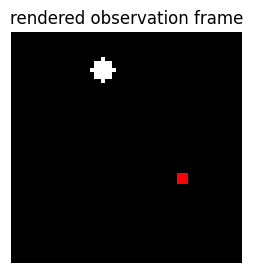

In [3]:
env = MovingBallWorld(seed=0)
obs = env.reset(seed=42)
print("initial state (hidden from agent):", np.round(env.state, 3))
print("observed position (noisy):        ", np.round(obs["position"], 3))
print("observed image shape:             ", obs["image"].shape, obs["image"].dtype)

for t in range(5):
    obs, reward, done, info = env.step(action=0)  # action 0 = push (-1, -1)
    print(f"t={t}  state={np.round(info['state'], 3)}  reward={reward:+.4f}  done={done}")

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(env.render())
ax.set_title("rendered observation frame")
ax.axis("off")
plt.show()

## 3. Rollout with a random policy

**Why:** a world model is only useful in the context of *trajectories* — sequences of `(state, action, observation, reward)`. Here we generate one with the simplest possible policy (uniform random actions) and record everything. In Lab 2, exactly this kind of logged data will become the training set for a learned model.

In [4]:
env = MovingBallWorld(seed=7)
obs = env.reset()
rng = np.random.default_rng(1)

frames, traj = [env.render()], []
T = 150
for t in range(T):
    a = int(rng.integers(0, 9))
    obs, reward, done, info = env.step(a)
    frames.append(env.render())
    s = info["state"]
    traj.append((t, a, s[0], s[1], s[2], s[3],
                 obs["position"][0], obs["position"][1], reward))
    if done:
        break

print(f"rollout finished after {len(traj)} steps; {len(frames)} frames recorded")

rollout finished after 38 steps; 39 frames recorded


In [5]:
# trajectory table: state vs. observation vs. action vs. reward
header = f"{'t':>4} {'action':>7} | {'x':>6} {'y':>6} {'vx':>6} {'vy':>6} | {'ox':>6} {'oy':>6} | {'reward':>8}"
print(header)
print("-" * len(header))
for row in traj[:12]:
    t, a, x, y, vx, vy, ox, oy, r = row
    print(f"{t:>4} {a:>7} | {x:6.3f} {y:6.3f} {vx:6.3f} {vy:6.3f} | {ox:6.3f} {oy:6.3f} | {r:8.4f}")
print(f"... ({len(traj) - 12} more rows)")

   t  action |      x      y     vx     vy |     ox     oy |   reward
---------------------------------------------------------------------
   0       4 |  0.588  0.778  0.000  0.000 |  0.588  0.789 |  -0.4821
   1       4 |  0.588  0.778  0.000  0.000 |  0.584  0.773 |  -0.4821
   2       6 |  0.607  0.758  0.196 -0.196 |  0.611  0.761 |  -0.4589
   3       8 |  0.646  0.759  0.388  0.004 |  0.647  0.752 |  -0.4536
   4       0 |  0.664  0.740  0.184 -0.192 |  0.664  0.745 |  -0.4329
   5       1 |  0.663  0.721 -0.015 -0.188 |  0.652  0.717 |  -0.4142
   6       7 |  0.681  0.702  0.181 -0.185 |  0.666  0.692 |  -0.3949
   7       8 |  0.718  0.704  0.373  0.015 |  0.704  0.702 |  -0.3970
   8       2 |  0.735  0.725  0.170  0.211 |  0.725  0.727 |  -0.4194
   9       2 |  0.732  0.765 -0.030  0.403 |  0.734  0.764 |  -0.4592
  10       7 |  0.749  0.805  0.167  0.395 |  0.729  0.800 |  -0.5002
  11       3 |  0.765  0.824  0.164  0.191 |  0.765  0.825 |  -0.5211
... (26 more rows)


## 4. Animate the rollout

**Why:** numbers in a table rarely reveal bugs; a 1-second glance at an animation does. Watch for plausible inertia (the ball keeps drifting after the force stops), energy loss at wall hits, and the friction slow-down. We also save the GIF to `assets/rollout.gif` — committing artifacts like this makes results inspectable directly on GitHub.

In [6]:
imageio.mimsave("assets/rollout.gif", frames[::2], duration=0.08)

fig = plt.figure(figsize=(3, 3))
plt.axis("off")
im = plt.imshow(frames[0])

def _update(i):
    im.set_data(frames[i])
    return [im]

anim = FuncAnimation(fig, _update, frames=len(frames), interval=60, blit=True)
plt.close(fig)
print("saved assets/rollout.gif")
HTML(anim.to_jshtml())

saved assets/rollout.gif


## 5. Observation ≠ State (the POMDP point)

**Why this matters:** the agent never sees `s = (x, y, vx, vy)`. It sees a **noisy position** and a **rendered image**. Two consequences:

1. **Noise** — the observed position jitters around the true one (run the cell below).
2. **Hidden variables** — neither the noisy position nor a single image contains *velocity*. Yet velocity is required to predict the future: two identical images can correspond to a ball moving left or right.

A problem where the observation does not fully determine the state is a **POMDP** (Partially Observable Markov Decision Process). The classical fix is *state estimation* — the Kalman filter of Lab 1. The modern fix is to *learn* a latent state that summarizes the past — Lab 2.

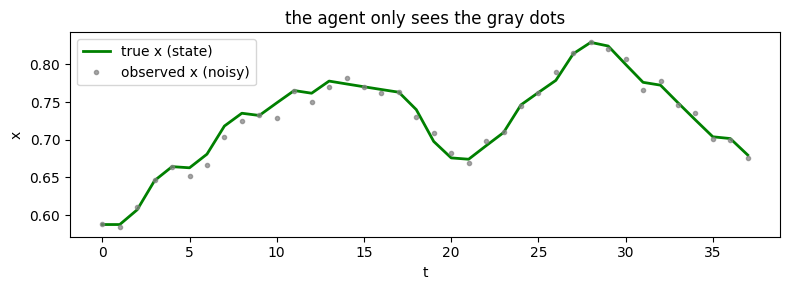

mean |obs - true| = 0.0057 (obs noise std = 0.0078)


In [7]:
xs_true = np.array([row[2] for row in traj])
xs_obs = np.array([row[6] for row in traj])
plt.figure(figsize=(8, 3))
plt.plot(xs_true, color="green", lw=2, label="true x (state)")
plt.plot(xs_obs, "o", color="gray", ms=3, alpha=0.7, label="observed x (noisy)")
plt.xlabel("t")
plt.ylabel("x")
plt.title("the agent only sees the gray dots")
plt.legend()
plt.tight_layout()
plt.show()

print(f"mean |obs - true| = {np.mean(np.abs(xs_obs - xs_true)):.4f} (obs noise std = {env.obs_noise / env.size:.4f})")

## ✏️ Exercise 1 — How much does friction matter?

Change the world parameters and observe how the rollout changes.

**Task:** rerun the rollout with `friction=1.0` (no damping) and with `friction=0.9` (heavy damping). In which world does the random policy reach the goal more often? Why?

**Hint:** you only need to change one constructor argument. With `friction=1.0` the only energy loss comes from wall bounces — watch the ball's speed over time in both cases.

In [8]:
# YOUR CODE HERE
# hint: env = MovingBallWorld(seed=7, friction=...) then reuse the rollout loop from Section 3
pass

## ✏️ Exercise 2 — A greedy policy instead of random

**Task:** implement a policy that, at each step, picks the action (from the 9 force combinations) whose direction best matches the vector from the **observed** (noisy) ball position to the goal. Does it reach the goal faster than the random policy? Does observation noise ever make it push the wrong way?

**Hint:** compute `d = goal - obs["position"]`, then choose `ax = sign(d[0])`, `ay = sign(d[1])` and find the index of `(ax, ay)` in `env.ACTION_TABLE`. Note you may pass the tuple `(ax, ay)` directly to `step()`.

In [9]:
# YOUR CODE HERE
# hint:
#   obs = env.reset()
#   for t in range(150):
#       d = env.goal - obs["position"]
#       action = (int(np.sign(d[0])), int(np.sign(d[1])))
#       obs, reward, done, info = env.step(action)
#       ...
pass

## ✏️ Exercise 3 (optional) — The `gymnasium.Env` convention

Real RL libraries expect environments to follow a standard interface so algorithms can treat them uniformly. **Task:** without installing anything, sketch a wrapper class `GymMovingBall` around `MovingBallWorld` that follows the `gymnasium.Env` convention:

- `reset(seed=...) -> (obs, info)` — note the *tuple* return (gymnasium ≥0.26),
- `step(action) -> (obs, reward, terminated, truncated, info)` — 5 return values,
- `self.action_space` / `self.observation_space` descriptors.

**Hint:** our `step` already returns `(obs, reward, done, info)` — the main work is splitting `done` into `terminated` (goal reached) vs. `truncated` (time limit). You can check your sketch mentally against `import gymnasium as gym; gym.Env` if you have it installed, but this is not required.

In [10]:
# YOUR CODE HERE (optional)
# class GymMovingBall:
#     def __init__(self, ...): ...
#     def reset(self, seed=None): ...
#     def step(self, action): ...
pass

## Summary

- You built a complete environment loop by hand: **state → action → transition → observation → reward**.
- Semi-implicit Euler + friction + inelastic bounces give stable, plausible dynamics at trivial compute cost.
- The rollout produced a trajectory dataset and a GIF (`assets/rollout.gif`) — the same data format a learned world model will train on.
- The key conceptual takeaway: **observation ≠ state** (noise + hidden velocity), which makes our world a POMDP.

**Next: Lab 1 — Kalman Filter.** How do we recover an estimate of the true state (position *and* velocity) from those noisy gray dots? The classical answer: recursive Bayesian state estimation.

*Course: World Models & Spatial Intelligence. Related: Ha & Schmidhuber (2018), World Models; Kaelbling et al. (1998), POMDPs.*